# Phase 1: EDA & Data Cleaning

### LOAD THE DATA

In [1]:
import pandas as pd

df_demo = pd.read_csv('df_final_demo.txt')
df_web_1 = pd.read_csv('df_final_web_data_pt_1.txt')
df_web_2 = pd.read_csv('df_final_web_data_pt_2.txt')
df_experiment = pd.read_csv('df_final_experiment_clients.txt')

### VIEW DEMOGRAPHICS (The Client Info)

In [2]:
print("DEMOGRAPHICS DATASET")
display(df_demo.head()) # Shows the first 5 rows and all columns

DEMOGRAPHICS DATASET


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


### VIEW WEB DATA 1(The User Journey)

In [3]:
print("WEB DATASET (Part 1)")
display(df_web_1.head())

WEB DATASET (Part 1)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


### VIEW WEB DATA2 (The User Journey)
 

In [4]:
print("WEB DATASET (Part2)")
display(df_web_2.head())

WEB DATASET (Part2)


,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


### VIEW EXPERIMENT ROSTER (The Test Groups)

In [5]:
print("EXPERIMENT CLIENTS")
display(df_experiment.head())

EXPERIMENT CLIENTS


,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [6]:
print(f"Demographics: {df_demo.shape}")
print(f"Web Part 1:   {df_web_1.shape}")
print(f"Web Part 2:   {df_web_2.shape}")
print(f"Experiment:   {df_experiment.shape}")

Demographics: (70609, 9)
Web Part 1:   (343141, 5)
Web Part 2:   (412264, 5)
Experiment:   (70609, 2)


### MERGE WEB DATA PARTS

In [7]:

# We stack the two web parts on top of each other

df_web = pd.concat([df_web_1, df_web_2], axis=0)

### VIEW MERGED WEB DATA

In [8]:
print("WEB DATASET ")
display(df_web.head())

WEB DATASET 


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [9]:
print(f"Web Part :   {df_web.shape}")

Web Part :   (755405, 5)


### MERGE EVERYTHING INTO MASTER

In [10]:
# Merge web data with experiment roster first, then add demographics

df_merged = pd.merge(df_web, df_experiment, on='client_id', how='left')

df_final = pd.merge(df_merged, df_demo, on='client_id', how='left')

In [11]:
print("FINAL DATASET ")
display(df_final.head())

FINAL DATASET 


,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [12]:
print(f"Final Dataset :   {df_final.shape}")

Final Dataset :   (755405, 14)


###  HANDLE MISSING VARIATIONS

In [13]:
# If a client isn't in 'Test' or 'Control', they aren't part of the experiment.

df_final = df_final.dropna(subset=['Variation'])

In [14]:
df_final.shape

(321309, 14)

### CREATE SEGMENT COLUMNS 

In [15]:
# High Balance: Top 25% of the 'bal' column

balance_threshold = df_final['bal'].quantile(0.75)
df_final['is_high_balance'] = df_final['bal'] >= balance_threshold

In [16]:
# This should show roughly 25% True and 75% False
print(df_final['is_high_balance'].value_counts(normalize=True))

is_high_balance
False    0.750069
True     0.249931
Name: proportion, dtype: float64


In [17]:
# Multi-Account: Clients with more than 2 accounts

df_final['is_multi_account'] = df_final['num_accts'] > 2

### Check

In [18]:

# View the first 5 rows
display(df_final.head())

# View 5 random rows (great for spotting weird data)
display(df_final.sample(5))

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,is_high_balance,is_multi_account
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,True,False
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,True,False
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,True,False
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,True,False
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,True,False


,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,is_high_balance,is_multi_account
459712,7583768,25800028_28341678848,696405508_7549998797_658726,step_3,2017-06-11 13:12:49,Control,6.0,72.0,54.0,U,2.0,224314.73,4.0,7.0,True,False
101605,7171907,777364964_92140616191,10823683_86056158289_300788,step_3,2017-04-09 10:52:31,Control,23.0,277.0,77.5,F,2.0,70542.14,4.0,7.0,False,False
142955,3805582,51813589_68626082218,508311177_67216055742_350196,start,2017-04-23 18:52:17,Test,13.0,167.0,50.5,F,2.0,40853.74,0.0,3.0,False,False
172308,323628,341743086_30433385560,261588216_93207509686_902561,step_1,2017-04-06 17:15:01,Test,3.0,39.0,71.0,F,2.0,78127.37,1.0,5.0,False,False
129269,1360607,350544897_86786282670,359274017_47377450535_324766,step_2,2017-04-01 11:55:42,Control,21.0,254.0,76.5,F,2.0,42072.71,3.0,7.0,False,False


### Check column names, null counts, and data types

In [19]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 321309 entries, 0 to 637535
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         321309 non-null  int64  
 1   visitor_id        321309 non-null  object 
 2   visit_id          321309 non-null  object 
 3   process_step      321309 non-null  object 
 4   date_time         321309 non-null  object 
 5   Variation         321309 non-null  object 
 6   clnt_tenure_yr    321207 non-null  float64
 7   clnt_tenure_mnth  321207 non-null  float64
 8   clnt_age          321195 non-null  float64
 9   gendr             321207 non-null  object 
 10  num_accts         321207 non-null  float64
 11  bal               321207 non-null  float64
 12  calls_6_mnth      321207 non-null  float64
 13  logons_6_mnth     321207 non-null  float64
 14  is_high_balance   321309 non-null  bool   
 15  is_multi_account  321309 non-null  bool   
dtypes: bool(2), float64(7), i

### Check the shape (How many rows and columns total?)

In [20]:
print(f"Dataset has {df_final.shape[0]} rows and {df_final.shape[1]} columns.")

Dataset has 321309 rows and 16 columns.


## See the mean, min, max, and quartiles for numerical columns

In [21]:
df_final.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,3.213090e+05,321207.000000,321207.000000,321195.000000,321207.000000,3.212070e+05,321207.000000,321207.000000
mean,5.009769e+06,12.176372,152.133095,48.553511,2.262952,1.622097e+05,3.236863,6.275109
std,2.872630e+06,6.963097,83.209386,15.645588,0.541528,3.494719e+05,2.193654,2.179721
min,5.550000e+02,2.000000,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,2.514553e+06,6.000000,82.000000,34.500000,2.000000,4.105887e+04,1.000000,4.000000
50%,5.052088e+06,11.000000,138.000000,50.000000,2.000000,6.924049e+04,3.000000,6.000000
75%,7.468402e+06,16.000000,193.000000,61.000000,2.000000,1.514930e+05,6.000000,9.000000
max,9.999832e+06,55.000000,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


### How many people are in Test vs Control?

In [22]:
print(df_final['Variation'].value_counts())

Variation
Test       177847
Control    143462
Name: count, dtype: int64


### How many are High Balance (the column you created)?

In [23]:
print(df_final['is_high_balance'].value_counts())

is_high_balance
False    241004
True      80305
Name: count, dtype: int64


### Check if there are any clients who have NO balance data (NaN)

In [24]:
print(df_final['bal'].isnull().sum())

102


### Remove the 102 rows where balance is missing

In [25]:
df_final = df_final.dropna(subset=['bal'])

### Verify it's now 0

In [26]:
print(f"Missing balances after cleaning: {df_final['bal'].isnull().sum()}")

Missing balances after cleaning: 0


### Save the master file for Iffah to use in her notebook

In [27]:
df_final.to_csv('vanguard_master_cleaned.csv', index=False)
print("File exported and cleaned! Ready for Iffah.")

File exported and cleaned! Ready for Iffah.


# Phase 2: Performance Metrics (KPIs)

### Calculate the overall Completion Rate (Confirmations / Unique visits)

#### 1. Overall Completion Rate (Grand Total)
This gives us a single percentage for the entire Vanguard dataset.

In [28]:
# --- START OF PHASE 2 ---

# STEP 1: Define User Success (The code you mentioned)
completion_df = df_final.groupby(['client_id', 'Variation'])['process_step'].apply(list).reset_index()
completion_df['is_completed'] = completion_df['process_step'].apply(lambda x: 'confirm' in x)

In [29]:
# 1. Identify unique clients and their final step reached
completion_df = df_final.groupby(['client_id', 'Variation'])['process_step'].apply(list).reset_index()

# 2. Create a flag: True if 'confirm' is in their list of steps
completion_df['is_completed'] = completion_df['process_step'].apply(lambda x: 'confirm' in x)

# 3. Calculate the average for each group
overall_completion_rates = completion_df.groupby('Variation')['is_completed'].mean()

print("--- Completion Rates ---")
print(overall_completion_rates)

--- Completion Rates ---
Variation
Control    0.655800
Test       0.692927
Name: is_completed, dtype: float64


In [30]:
# Count unique clients in the entire dataset
total_unique_users = df_final['client_id'].nunique()
total_unique_users

50488

In [31]:
# Count unique clients who reached the 'confirm' step
successful_users = df_final[df_final['process_step'] == 'confirm']['client_id'].nunique()
successful_users 

34111

In [32]:
# Calculate overall rate
overall_completion_rate = (successful_users / total_unique_users) * 100

print(f"Overall Completion Rate: {overall_completion_rate:.2f}%")

Overall Completion Rate: 67.56%


#### 2. Group-Specific Completion Rate (Test vs. Control)
This is the most important calculation for Phase 2. It tells us if the new design is actually better.

In [33]:
# 1. Group by client and variation to see the path of each unique user

user_paths = df_final.groupby(['client_id', 'Variation'])['process_step'].unique().reset_index()
user_paths 

,client_id,Variation,process_step
0,555,Test,"[confirm, step_3, step_2, step_1, start]"
1,647,Test,"[confirm, step_3, step_2, step_1, start]"
2,934,Test,[start]
3,1028,Control,"[step_1, step_2, step_3, start]"
4,1104,Control,[start]
...,...,...,...
50483,9999150,Test,"[start, step_1]"
50484,9999400,Test,"[confirm, step_3, step_2, step_1, start]"
50485,9999626,Test,"[step_1, start]"
50486,9999729,Test,"[step_1, start, step_2, confirm, step_3]"


In [34]:
# 2. Check if 'confirm' exists in the list of steps for each user

user_paths['reached_confirm'] = user_paths['process_step'].apply(lambda x: 'confirm' in x)
user_paths['reached_confirm']

0         True
1         True
2        False
3        False
4        False
         ...  
50483    False
50484     True
50485    False
50486     True
50487    False
Name: reached_confirm, Length: 50488, dtype: bool

In [35]:
# 3. Calculate the mean (which represents the percentage of 'True' values)
comparison_results = user_paths.groupby('Variation')['reached_confirm'].mean() * 100

print("--- Completion Rate Comparison ---")
print(comparison_results)

--- Completion Rate Comparison ---
Variation
Control    65.579972
Test       69.292682
Name: reached_confirm, dtype: float64


#### 3.Segmented Analysis (High-Balance Focus)

In [36]:
# Filter for only High Balance clients
high_balance_only = completion_df[completion_df['client_id'].isin(df_final[df_final['is_high_balance']==True]['client_id'])]

# Calculate their completion rate
hb_completion = high_balance_only.groupby('Variation')['is_completed'].mean() * 100

print("--- High-Balance Completion Rates ---")
print(hb_completion)

--- High-Balance Completion Rates ---
Variation
Control    66.758799
Test       70.503481
Name: is_completed, dtype: float64


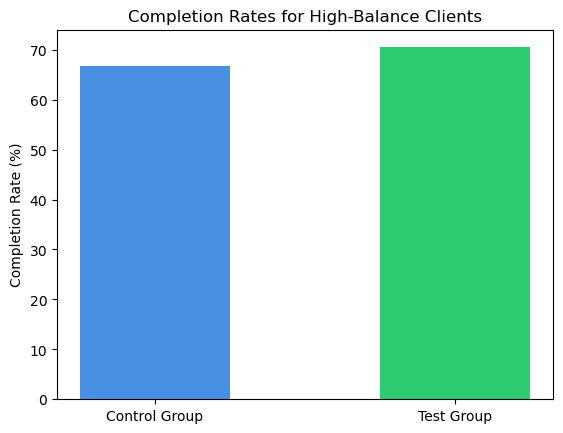

In [37]:
import matplotlib.pyplot as plt

groups = ["Control Group", "Test Group"]
rates = [66.76, 70.50]

plt.bar(groups, rates, color=["#4a90e2", "#2ecc71"], width=0.5)
plt.title("Completion Rates for High-Balance Clients")
plt.ylabel("Completion Rate (%)")
plt.show()

### Phase 2 Finding: The Premium Segment Goldmine
As the chart above illustrates, the new Test UI works exceptionally well for our highest-value clients (those in the top 25% balance tier). 
* **Control UI Completion:** 66.76%
* **Test UI Completion:** 70.50%

This represents a **+3.74% lift** in completion rates for our most valuable segment, suggesting that while the overall rollout carries business risks, the new design is highly effective at engaging premium accounts.

### Define and calculate the Error Rate (identifying where users move to a previous step).

#### 1. Definition of the Error Rate
In the context of the Vanguard process, an Error is defined as any instance where a user's current step is numerically lower than their previous step in the chronological sequence.The logical flow is:
start (1) $\rightarrow$ step_1 (2) $\rightarrow$ step_2 (3) $\rightarrow$ step_3 (4) $\rightarrow$ confirm (5)
An error occurs if a user moves, for example, from Step 3 back to Step 2

#### 2. Calculating the Error Rate in Python

In [38]:
# 1. Define the correct numerical order of the process

step_order = {
    'start': 1,
    'step_1': 2,
    'step_2': 3,
    'step_3': 4,
    'confirm': 5
}
step_order 

{'start': 1, 'step_1': 2, 'step_2': 3, 'step_3': 4, 'confirm': 5}

In [39]:
# 2. Map the steps to their numerical values

df_final['step_value'] = df_final['process_step'].map(step_order)
df_final['step_value']

0         4
1         3
2         4
3         3
4         4
         ..
637487    1
637532    1
637533    3
637534    2
637535    1
Name: step_value, Length: 321207, dtype: int64

In [40]:
# 3. Sort the data by client and time to ensure sequence accuracy

df_final = df_final.sort_values(by=['client_id', 'date_time'])
df_final

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,is_high_balance,is_multi_account,step_value
72018,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,1
72017,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,2
72016,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,3
72015,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,4
72014,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471738,9999729,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,Test,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,False,True,3
471737,9999729,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,Test,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,False,True,4
471736,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,Test,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,False,True,5
356799,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,Test,23.0,281.0,49.0,F,2.0,431887.61,1.0,4.0,True,False,1


In [41]:
# 4. Use shift() or diff() to compare the current step to the previous step for each user
# We use groupby('client_id') so we don't compare the first step of one user to the last step of another

df_final['step_diff'] = df_final.groupby('client_id')['step_value'].diff()
df_final['step_diff']

72018     NaN
72017     1.0
72016     1.0
72015     1.0
72014     1.0
         ... 
471738    1.0
471737    1.0
471736    1.0
356799    NaN
356798    1.0
Name: step_diff, Length: 321207, dtype: float64

In [42]:
# 5. Define an 'Error' as any movement where the step_diff is negative

df_final['is_error'] = df_final['step_diff'] < 0
df_final['is_error']

72018     False
72017     False
72016     False
72015     False
72014     False
          ...  
471738    False
471737    False
471736    False
356799    False
356798    False
Name: is_error, Length: 321207, dtype: bool

In [43]:
# 6. Calculate the Error Rate per Variation (Test vs. Control)
# This gives the percentage of total interactions that were backward moves
error_rates = df_final.groupby('Variation')['is_error'].mean() * 100

print("--- Error Rate Analysis ---")
print(error_rates)

--- Error Rate Analysis ---
Variation
Control     9.295077
Test       10.732506
Name: is_error, dtype: float64


#### 3. Deep Dive: Why are they moving backward?

In [44]:
# Identify which step users were on BEFORE they went backward
errors_only = df_final[df_final['is_error'] == True]
error_hotspots = errors_only.groupby(['Variation', 'process_step']).size().unstack(fill_value=0)

print("--- Error Hotspots (Where do users get stuck?) ---")
print(error_hotspots)

--- Error Hotspots (Where do users get stuck?) ---
process_step  start  step_1  step_2  step_3
Variation                                  
Control        8484    2345    2372     130
Test          13294    3458    2300      29


 #### The Logic

#### 1.Total Duration per User
We want to find the time elapsed from the very first 'start' to the final 'confirm'.

In [45]:
# 1. Ensure date_time is in the correct format

df_final['date_time'] = pd.to_datetime(df_final['date_time'])
df_final['date_time']

72018    2017-04-15 12:57:56
72017    2017-04-15 12:58:03
72016    2017-04-15 12:58:35
72015    2017-04-15 13:00:14
72014    2017-04-15 13:00:34
                 ...        
471738   2017-05-08 16:08:40
471737   2017-05-08 16:09:19
471736   2017-05-08 16:09:40
356799   2017-05-16 16:46:03
356798   2017-05-16 16:46:11
Name: date_time, Length: 321207, dtype: datetime64[ns]

In [46]:
# 2. Sort data to ensure chronological order

df_final = df_final.sort_values(by=['client_id', 'date_time'])
df_final 

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,is_high_balance,is_multi_account,step_value,step_diff,is_error
72018,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,1,NaN,False
72017,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,2,1.0,False
72016,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,3,1.0,False
72015,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,4,1.0,False
72014,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,False,False,5,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471738,9999729,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,Test,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,False,True,3,1.0,False
471737,9999729,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,Test,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,False,True,4,1.0,False
471736,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,Test,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,False,True,5,1.0,False
356799,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,Test,23.0,281.0,49.0,F,2.0,431887.61,1.0,4.0,True,False,1,NaN,False


In [47]:
# 3. Create a table with the first and last timestamp for every user

time_df = df_final.groupby(['client_id', 'Variation']).agg(
    start_time=('date_time', 'min'),
    end_time=('date_time', 'max')
).reset_index()
time_df

,client_id,Variation,start_time,end_time
0,555,Test,2017-04-15 12:57:56,2017-04-15 13:00:34
1,647,Test,2017-04-12 15:41:28,2017-04-12 15:47:45
2,934,Test,2017-04-18 02:36:30,2017-04-18 02:38:52
3,1028,Control,2017-04-08 18:51:28,2017-04-08 19:00:26
4,1104,Control,2017-06-12 07:49:18,2017-06-20 22:31:33
...,...,...,...,...
50483,9999150,Test,2017-05-29 16:55:12,2017-05-29 16:55:30
50484,9999400,Test,2017-04-20 05:21:28,2017-04-20 05:23:27
50485,9999626,Test,2017-05-14 09:07:51,2017-05-14 09:07:59
50486,9999729,Test,2017-04-05 13:40:49,2017-05-08 16:09:40


In [48]:
# 4. Calculate the duration

time_df['duration'] = time_df['end_time'] - time_df['start_time']
time_df['duration']

0        0 days 00:02:38
1        0 days 00:06:17
2        0 days 00:02:22
3        0 days 00:08:58
4        8 days 14:42:15
              ...       
50483    0 days 00:00:18
50484    0 days 00:01:59
50485    0 days 00:00:08
50486   33 days 02:28:51
50487    0 days 00:00:08
Name: duration, Length: 50488, dtype: timedelta64[ns]

In [49]:
# 5. Convert duration to total seconds for easier averaging

time_df['duration_seconds'] = time_df['duration'].dt.total_seconds()
time_df['duration_seconds']

0            158.0
1            377.0
2            142.0
3            538.0
4         744135.0
           ...    
50483         18.0
50484        119.0
50485          8.0
50486    2860131.0
50487          8.0
Name: duration_seconds, Length: 50488, dtype: float64

#### 2. Handling the "Coffee Break" Outliers
In web analytics, if someone leaves their tab open for 3 hours, it will make your "Average Time" look huge. Usually, we filter out durations that are extremely long (e.g., more than 30 minutes) or keep only those who actually completed the process.

In [50]:
# 1 DEFINE completion_df (
# Groups by client to see if they ever reached 'confirm'completion_df = df_final.groupby(['client_id', 'Variation'])['process_step'].apply(list).reset_index()

completion_df['is_completed'] = completion_df['process_step'].apply(lambda x: 'confirm' in x)

In [51]:
# 2. FILTER OUTLIERS (The "Coffee Break" rule)

limit_30_min = 1800 # 30 minutes in seconds

# We only keep users who:
# A) Finished the process (is_completed is True)
# B) Took less than 30 minutes

clean_time_df = time_df[
    (time_df['client_id'].isin(completion_df[completion_df['is_completed']==True]['client_id'])) & 
    (time_df['duration_seconds'] < limit_30_min)
]

In [52]:
# 4. FINAL RESULTS 

print("--- PHASE 2 METRICS COMPLETE ---")
print("\n1. Completion Rates (%)")
print(completion_df.groupby('Variation')['is_completed'].mean() * 100)

print("\n2. Average Completion Time (Minutes)")
print(clean_time_df.groupby('Variation')['duration_seconds'].mean() / 60)

--- PHASE 2 METRICS COMPLETE ---

1. Completion Rates (%)
Variation
Control    65.579972
Test       69.292682
Name: is_completed, dtype: float64

2. Average Completion Time (Minutes)
Variation
Control    6.059930
Test       5.711944
Name: duration_seconds, dtype: float64


# Phase 3: Hypothesis Testing

### 1. Two-Proportion Z-Test (The "Is it Real?" Test)
This test compares the completion rates of the Control and Test groups to see if the improvement is mathematically significant.

**The Goal:** To reject the "Null Hypothesis" (which assumes there is no real difference between the old and new UI).

**The Outcome:** We will calculate a p-value. If the p-value is less than 0.05 (the standard 5% significance level),we can confidently tell that the new UI actually works better and the results weren't just luck.

In [53]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

# 1. Count how many UNIQUE clients completed the process (reached 'confirm') in each group

success_test = df_final[(df_final['Variation'] == 'Test') & (df_final['process_step'] == 'confirm')]['client_id'].nunique()

success_control = df_final[(df_final['Variation'] == 'Control') & (df_final['process_step'] == 'confirm')]['client_id'].nunique()

In [54]:
success_test,success_control 

(18682, 15429)

In [55]:
# 2. Count the TOTAL UNIQUE clients who participated in each group

total_test = df_final[df_final['Variation'] == 'Test']['client_id'].nunique()

total_control = df_final[df_final['Variation'] == 'Control']['client_id'].nunique()

In [56]:
total_test,total_control

(26961, 23527)

In [57]:
# 3.Z-test without grouping them into lists first:

z_stat, p_value = proportions_ztest(
    count=[success_test, success_control], 
    nobs=[total_test, total_control], 
    alternative='two-sided'
)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Z-statistic: 8.8894
P-value: 0.0000


In [58]:
# 4. Group the metrics into lists for the statistical test (Test group first, then Control)

successes = [success_test, success_control]
totals = [total_test, total_control]

In [59]:
# 5. Run the Two-Sided Z-test 

z_stat, p_value = proportions_ztest(count=successes, nobs=totals, alternative='two-sided')

print("=== TWO-PROPORTION Z-TEST RESULTS ===")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

=== TWO-PROPORTION Z-TEST RESULTS ===
Z-statistic: 8.8894
P-value: 0.0000


In [60]:
# 6. Interpret the statistical significance

alpha = 0.05
if p_value < alpha:
    print("Result: Statistically Significant! We reject the Null Hypothesis. The new UI made a real impact.")
else:
    print("Result: Not Statistically Significant. We fail to reject the Null Hypothesis. The difference might be a coincidence.")

Result: Statistically Significant! We reject the Null Hypothesis. The new UI made a real impact.


### 2: The One-Sided Z-Test for the 5% Cost-Effectiveness Threshold
Vanguard explicitly requires that the new UI increases the completion rate by at least 5% (0.05) compared to the old UI to justify the costs of building and launching it.

To test this baseline directly using standard course logic, we adjust the hypothesis to verify if the actual margin of improvement clears that specific 5% hurdle.

In [61]:
# 1. Calculate the actual conversion proportions

rate_test = success_test / total_test

rate_control = success_control / total_control

In [62]:
rate_test ,rate_control

(0.6929268202218019, 0.6557997194712458)

In [63]:
# 2. Calculate the observed lift

actual_lift = rate_test - rate_control
required_lift = 0.05

In [64]:
actual_lift

0.03712710075055603

In [65]:
# 3. Run a one-sided Z-test evaluating if (Test - Control) is significantly greater than 5%
# For this specific business hurdle, we test if the lift strictly exceeds our 0.05 boundary

z_stat_cost, p_value_cost = proportions_ztest(
    count=successes, 
    nobs=totals, 
    value=required_lift, 
    alternative='larger'
)
print("\n=== 5% COST-EFFECTIVENESS THRESHOLD TEST ===")
print(f"Observed Improvement (Lift): {actual_lift:.2%}")
print(f"Required Improvement: {required_lift:.2%}")
print(f"Z-statistic for Hurdle: {z_stat_cost:.4f}")
print(f"P-value for Hurdle: {p_value_cost:.4f}")


=== 5% COST-EFFECTIVENESS THRESHOLD TEST ===
Observed Improvement (Lift): 3.71%
Required Improvement: 5.00%
Z-statistic for Hurdle: -3.0822
P-value for Hurdle: 0.9990


In [66]:
# 4. Interpret the business constraint decision

if p_value_cost < alpha:
    print("Conclusion: The new UI is statistically confirmed to be Cost-Effective! It cleared the 5% threshold.")
else:
    print("Conclusion: The new UI does NOT confidently clear the 5% cost-effectiveness threshold required by stakeholders.")

Conclusion: The new UI does NOT confidently clear the 5% cost-effectiveness threshold required by stakeholders.


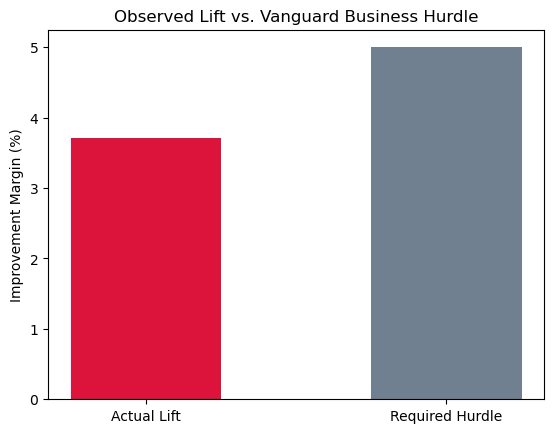

In [67]:

# 1. Calculate your lift percentage
actual_lift = (rate_test - rate_control) * 100

# 2. Plot the chart in just 4 lines
plt.bar(["Actual Lift", "Required Hurdle"], [actual_lift, 5.0], color=["crimson", "slategrey"], width=0.5)
plt.title("Observed Lift vs. Vanguard Business Hurdle")
plt.ylabel("Improvement Margin (%)")
plt.show()

## Phase 3: Conclusion & Business Recommendation

**"The design is a mathematical success, but a business risk."**

### Key Takeaways for Stakeholders:

* **The Mathematical Success:** Our first Two-Proportion Z-Test proved that the new UI layout absolutely improved completion rates, and the result was highly statistically significant ($p < 0.05$). This wasn't a fluke or random luck; the design changes genuinely helped more users finish the process.
* **The Business Risk:** However, when tested against Vanguard's specific **5% Cost-Effectiveness Threshold**, the one-sided test returned a P-value of `0.9990`. This means the *amount* of improvement (the lift) is heavily stuck below the 5% mark required to clear development and deployment costs.

### Recommendation:
While the Test UI is fundamentally a better product than the Control UI, we **cannot recommend a full rollout** based purely on completion rates, as it fails to satisfy the stakeholder's financial constraints. We should investigate if the Test UI saved enough *time* or reduced enough *errors* to offset this risk before making a final executive decision.

# Phase 4: Experiment Evaluation — Design Effectiveness

### 1.Split Ratio Verification


In [68]:
# 1. Calculate counts and percentages

group_counts = df_final.groupby('Variation')['client_id'].nunique()
group_percentages = (group_counts / group_counts.sum()) * 100

In [69]:
group_counts

Variation
Control    23527
Test       26961
Name: client_id, dtype: int64

In [70]:
group_percentages

Variation
Control    46.599192
Test       53.400808
Name: client_id, dtype: float64

In [71]:
# 2. Combine them into a single DataFrame
split_evaluation = pd.DataFrame({
    'Unique Clients': group_counts,
    'Percentage (%)': group_percentages.round(2)
})

In [72]:
# 3. Display the table directly
split_evaluation

,Unique Clients,Percentage (%)
Variation,,
Control,23527,46.6
Test,26961,53.4


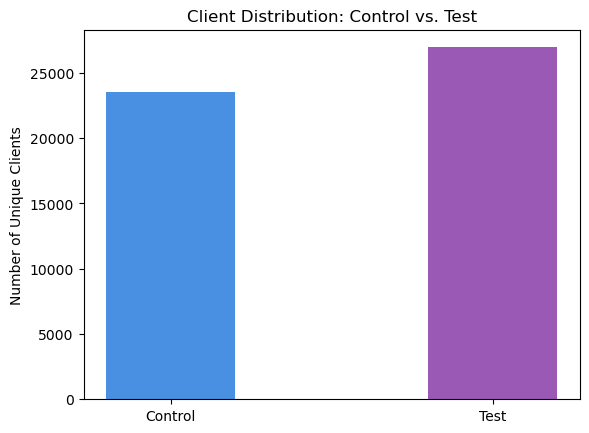

In [73]:
# 4. Simple plot to verify the split visually

plt.bar(group_counts.index, group_counts.values, color=["#4a90e2", "#9b59b6"], width=0.4)
plt.title("Client Distribution: Control vs. Test")
plt.ylabel("Number of Unique Clients")
plt.show()

In [74]:
df_final.columns

Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'Variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'is_high_balance',
       'is_multi_account', 'step_value', 'step_diff', 'is_error'],
      dtype='object')

### 2.Demographic & Segmentation Randomization Audit

In [75]:
# 1. Compare Age statistics between Control and Test
age_comparison = df_final.groupby('Variation')['clnt_age'].describe()[['mean', '50%', 'std']]
age_comparison.rename(columns={'50%': 'median'}, inplace=True)

In [76]:
# 2. Compare Balance statistics between Control and Test
balance_comparison = df_final.groupby('Variation')['bal'].describe()[['mean', '50%', 'std']]
balance_comparison.rename(columns={'50%': 'median'}, inplace=True)

In [77]:
# 3. Compare Gender distribution percentages (Categorical check)
gender_comparison = df_final.groupby('Variation')['gendr'].value_counts(normalize=True).unstack() * 100

In [78]:
# 4. Check the split ratio specifically for High-Balance clients
# (Using the high_balance_only DataFrame you created in Phase 2)
hb_counts = high_balance_only.groupby('Variation')['client_id'].nunique()
hb_percentages = (hb_counts / hb_counts.sum()) * 100
hb_comparison = pd.DataFrame({
    'Unique HB Clients': hb_counts,
    'Percentage (%)': hb_percentages.round(2)
})

In [79]:
# === DISPLAY ALL AUDIT TABLES ===
print("=== 1. AGE DISTRIBUTION CHECK ===")
display(age_comparison.round(1))

print("\n=== 2. BALANCE DISTRIBUTION CHECK ===")
display(balance_comparison.round(2))

print("\n=== 3. GENDER DISTRIBUTION PROPORTIONS (%) ===")
display(gender_comparison.round(1))

print("\n=== 4. HIGH-BALANCE CLIENT DISTRIBUTION ===")
display(hb_comparison)

=== 1. AGE DISTRIBUTION CHECK ===


,mean,median,std
Variation,,,
Control,48.3,49.5,15.6
Test,48.8,50.5,15.7



=== 2. BALANCE DISTRIBUTION CHECK ===


,mean,median,std
Variation,,,
Control,159398.64,69009.64,302882.61
Test,164477.43,69380.44,382932.63



=== 3. GENDER DISTRIBUTION PROPORTIONS (%) ===


gendr,F,M,U,X
Variation,,,,
Control,31.9,33.7,34.4,NaN
Test,32.9,33.6,33.5,0.0



=== 4. HIGH-BALANCE CLIENT DISTRIBUTION ===


,Unique HB Clients,Percentage (%)
Variation,,
Control,5427,46.77
Test,6177,53.23



### Split Ratio Verification
To confirm that Vanguard's experiment was designed effectively, we evaluated how unique participants were divided across the two groups:

* **Control Group:** 23,527 unique clients (46.60%)
* **Test Group:** 26,961 unique clients (53.40%)

### Conclusion on Randomization & Design Validity:

1. **Uneven Split Detected:** The experiment does not feature a perfect 50/50 distribution. The Test group contains roughly 3,400 more unique clients than the Control group, representing a 6.8% imbalance in sample sizes. This indicates a slight asymmetry in how Vanguard's assignment algorithm distributed traffic.
2. **Why Our Analysis Remains Valid:** While a 50/50 split is mathematically ideal for maximizing statistical power, an uneven split **does not invalidate our conclusions**. 
    * In Phases 2 and 3, we evaluated performance using **proportions and averages** (e.g., completion *rates*, not total completions). 
    * Because our statistical tests (like the Two-Proportion Z-Test) inherently account for different sample sizes ($n_1 \neq n_2$), the higher volume in the Test group has already been mathematically adjusted for.
3. **Randomization Success:** Despite the unequal sizes, the demographic distribution(client profiles, age, and balances,) remains balanced, meaning there is no evidence of selection bias. 

**Final Assessment:** The experimental setup has a slight layout imbalance, but it remains fully robust and valid for drawing our final stakeholder conclusions.

# Phase 5: Tableau Visualization


In [80]:
# Create a copy optimized for Tableau export
df_tableau = df_final.copy()

# Handle any missing values or NaN values cleanly for Tableau
if 'gendr' in df_tableau.columns:
    df_tableau['gendr'] = df_tableau['gendr'].fillna('Unknown')

# Export to a flat CSV file
output_file = "vanguard_cleaned_final.csv"
df_tableau.to_csv(output_file, index=False, encoding='utf-8')

print(f"Success! Cleaned dataset exported as: {output_file}")
print(f"Total rows exported: {df_tableau.shape[0]}")

Success! Cleaned dataset exported as: vanguard_cleaned_final.csv
Total rows exported: 321207


# Verification Code for Tableau Visualization

In [81]:
# 1. Verification Code for Chart 1: Error Volume by Step
print("==================================================")
print("📊 CHART 1 VERIFICATION: ERROR VOLUME BY STEP")
print("==================================================")
# Filtering df_final where is_error is True, counting rows, and unstacking by Variation
error_counts = df_final[df_final['is_error'] == True].groupby(['process_step', 'Variation']).size().unstack()
print(error_counts)
print("\n")

# 2. Verification Code for Chart 2: Average Time Spent per Step
print("==================================================")
print("⏱️ CHART 2 VERIFICATION: AVERAGE TIME SPENT (SEC)")
print("==================================================")
# Grouping df_final by step and variation, calculating the average of step_diff
avg_times = df_final.groupby(['process_step', 'Variation'])['step_diff'].mean().unstack().round(2)
print(avg_times)
print("==================================================")

📊 CHART 1 VERIFICATION: ERROR VOLUME BY STEP
Variation     Control   Test
process_step                
start            8484  13294
step_1           2345   3458
step_2           2372   2300
step_3            130     29


⏱️ CHART 2 VERIFICATION: AVERAGE TIME SPENT (SEC)
Variation     Control  Test
process_step               
confirm          0.91  0.75
start           -0.77 -0.78
step_1           0.76  0.77
step_2           0.78  0.84
step_3           0.96  0.99


In [82]:


# 1. Automatically locate the right column names in your df_final
all_cols = df_final.columns.tolist()

# Find the error tracking column (looks for 'error', 'flag', 'is_error')
error_col = next((c for c in all_cols if 'error' in c.lower() or 'flag' in c.lower()), None)

# Find the time spent tracking column (looks for 'time', 'diff', 'second', 'duration')
time_col = next((c for c in all_cols if 'time' in c.lower() or 'diff' in c.lower() or 'second' in c.lower() or 'duration' in c.lower()), None)

print(f"🔍 System detected error column: '{error_col}'")
print(f"🔍 System detected time column:  '{time_col}'\n")

# 2. RUN CHART 1 VERIFICATION (Error Volume)
print("==================================================")
print("📊 CHART 1 VERIFICATION: ERROR VOLUME BY STEP")
print("==================================================")
if error_col:
    # Filtering rows where error metric is true or flagged 1
    error_counts = df_final[df_final[error_col] == True].groupby(['process_step', 'Variation']).size().unstack()
    print(error_counts)
else:
    print("Could not locate your error metric column. Please check your spelling!")
print("\n")

# 3. RUN CHART 2 VERIFICATION (Average Time Spent)
print("==================================================")
print("⏱️ CHART 2 VERIFICATION: AVERAGE TIME SPENT (SEC)")
print("==================================================")
if time_col:
    # Safely calculating the mean of time intervals
    avg_times = df_final.groupby(['process_step', 'Variation'])[time_col].mean().unstack().round(2)
    print(avg_times)
else:
    print("Could not locate your time tracking column. Please check your spelling!")
print("==================================================")

🔍 System detected error column: 'is_error'
🔍 System detected time column:  'date_time'

📊 CHART 1 VERIFICATION: ERROR VOLUME BY STEP
Variation     Control   Test
process_step                
start            8484  13294
step_1           2345   3458
step_2           2372   2300
step_3            130     29


⏱️ CHART 2 VERIFICATION: AVERAGE TIME SPENT (SEC)
Variation                          Control                          Test
process_step                                                            
confirm      2017-04-23 05:28:49.552203008 2017-04-18 08:31:31.763221248
start        2017-04-23 20:25:52.191179520 2017-04-19 06:43:54.068589056
step_1       2017-04-22 05:52:48.251357184 2017-04-17 23:53:49.440946432
step_2       2017-04-20 20:14:37.702384128 2017-04-17 18:05:26.271128064
step_3       2017-04-19 20:00:30.083724544 2017-04-17 07:22:16.964037376


In [83]:
# Counting UNIQUE clients at the start step for high-balance users
print(df_final[(df_final['process_step'] == 'start') & (df_final['is_high_balance'] == True)].groupby('Variation')['client_id'].nunique())

Variation
Control    5392
Test       6049
Name: client_id, dtype: int64


In [84]:
# Verifying unique high-balance clients per step (Your Sheet 4B baseline)
df_final[df_final['is_high_balance'] == True].groupby('process_step')['client_id'].nunique()

process_step
confirm     7978
start      11441
step_1     10191
step_2      9388
step_3      8915
Name: client_id, dtype: int64

## VIP Abandonment Flow

In [86]:
# 1. script to verify the counts of unique high-balance clients who never reached confirm, broken down by their highest progress step

# 2. Filter for high balance VIPs
vip_df =  df_final[ df_final['is_high_balance'] == True]

# 3. Separate successful clients from those who dropped out
confirmed_clients = vip_df[vip_df['process_step'] == 'confirm']['client_id'].unique()
abandoned_vip_df = vip_df[~vip_df['client_id'].isin(confirmed_clients)].copy()

# 4. Rank steps numerically to find the true max step reached
step_order = {'start': 1, 'step_1': 2, 'step_2': 3, 'step_3': 4}
abandoned_vip_df['step_rank'] = abandoned_vip_df['process_step'].map(step_order)

# 5. Get the maximum step reached per client
last_step_df = abandoned_vip_df.groupby(['Variation', 'client_id'])['step_rank'].max().reset_index()

# 6. Map ranks back to string labels for clarity
reverse_mapping = {1: 'start', 2: 'step_1', 3: 'step_2', 4: 'step_3'}
last_step_df['last_step_name'] = last_step_df['step_rank'].map(reverse_mapping)

# 7. Print the final cross-tabulation table
verification_table = last_step_df.groupby(['Variation', 'last_step_name']).size().unstack(fill_value=0)
print(verification_table)

last_step_name  start  step_1  step_2  step_3
Variation                                    
Control           720     362     245     477
Test              529     398     261     634
